# Compress a grayscale image

In [4]:
# reduces storage and speeds up image processing.
# PCA keeps the “most informative pixel patterns” (edges, shapes) while dropping small variations

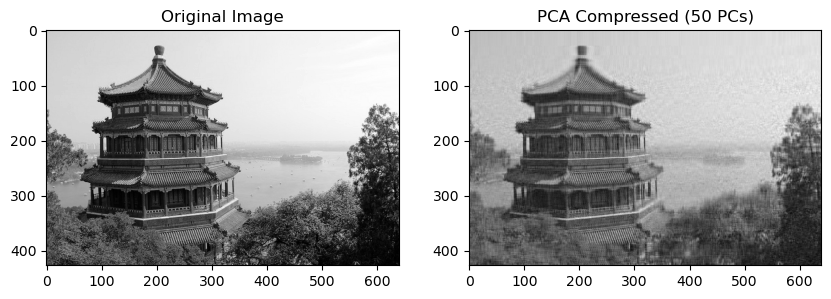

In [8]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_sample_image
import numpy as np

# Load sample image (China.jpg)
china = load_sample_image("china.jpg")
gray = np.mean(china, axis=2) / 255.0  # convert to grayscale (0-1 scale)

# Apply PCA
pca = PCA(50)  # keep 50 principal components
gray_pca = pca.fit_transform(gray)
gray_reconstructed = pca.inverse_transform(gray_pca)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Original Image")
plt.subplot(1,2,2)
plt.imshow(gray_reconstructed, cmap='gray')
plt.title("PCA Compressed (50 PCs)")
plt.show()


# Facial Recognition

In [9]:
# In facial recognition systems, images have thousands of pixels. PCA (Eigenfaces) helps extract key facial features 
#(principal components) to represent each face efficiently.

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to C:\Users\Lenovo\scikit_learn_data


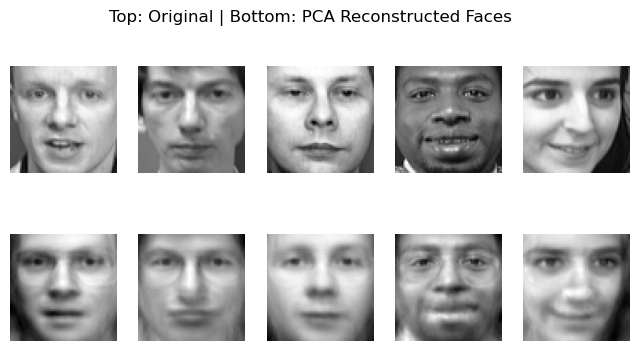

In [10]:
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

faces = fetch_olivetti_faces(shuffle=True, random_state=42)
pca = PCA(n_components=25, whiten=True, random_state=42)
faces_pca = pca.fit_transform(faces.data)

# Show original vs PCA reconstructed
reconstructed = pca.inverse_transform(faces_pca)
plt.figure(figsize=(8,4))
for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(faces.images[i], cmap='gray')
    plt.axis('off')
    plt.subplot(2,5,5+i+1)
    plt.imshow(reconstructed[i].reshape(64,64), cmap='gray')
    plt.axis('off')
plt.suptitle("Top: Original | Bottom: PCA Reconstructed Faces")
plt.show()


# Financial Data – Stock Market Patterns

In [ ]:
# You have 100 stock price movements — many are correlated. 
#PCA helps identify a few key trends (market factors) driving all of them.

In [12]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA

# Simulated daily stock returns for 10 companies
np.random.seed(42)
data = np.random.randn(100, 10) * 0.02 + np.linspace(0, 0.05, 100).reshape(-1, 1)
df = pd.DataFrame(data, columns=[f'Stock_{i}' for i in range(1, 11)])
print(df)

# Apply PCA
pca = PCA()
pca.fit(df)

explained = np.cumsum(pca.explained_variance_ratio_)

print("Cumulative variance explained by first 3 components:", explained[:3])


     Stock_1   Stock_2   Stock_3   Stock_4   Stock_5   Stock_6   Stock_7  \
0   0.009934 -0.002765  0.012954  0.030461 -0.004683 -0.004683  0.031584   
1  -0.008763 -0.008810  0.005344 -0.037761 -0.033993 -0.010741 -0.019752   
2   0.030323 -0.003505  0.002361 -0.027485 -0.009878  0.003229 -0.022010   
3  -0.010519  0.038561  0.001245 -0.019639  0.017966 -0.022902  0.005692   
4   0.016790  0.005448 -0.000293 -0.004002 -0.027550 -0.012377 -0.007193   
..       ...       ...       ...       ...       ...       ...       ...   
95  0.043155  0.055021  0.022949  0.076855  0.046337  0.070326  0.054834   
96  0.061339  0.075068  0.052415  0.062665  0.046690  0.077287  0.034957   
97  0.051552  0.035369  0.065803  0.035937  0.040066  0.011199  0.039944   
98  0.065211  0.058004  0.030155  0.048541  0.049423  0.026328  0.079563   
99  0.054168  0.009165  0.045056  0.036360  0.029968  0.044378  0.085954   

     Stock_8   Stock_9  Stock_10  
0   0.015349 -0.009389  0.010851  
1   0.006790 -0.0

# Healthcare / Disease Detection

In [ ]:
# A dataset with 30+ medical test results per patient. 
#PCA can identify the key combinations of tests that explain most variation in patient outcomes.

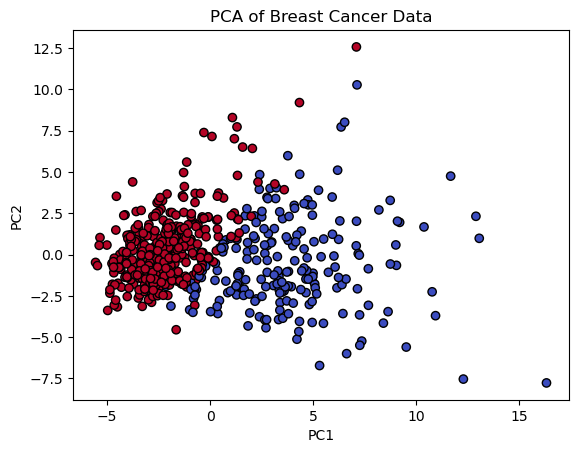

In [13]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

data = load_breast_cancer()
X = StandardScaler().fit_transform(data.data)
y = data.target

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='coolwarm', edgecolor='k')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Breast Cancer Data")
plt.show()


In [ ]:
# Compress a grayscale image

In [ ]:
# principal components display

Original image shape: (427, 640)
PCA compressed shape: (427, 50)


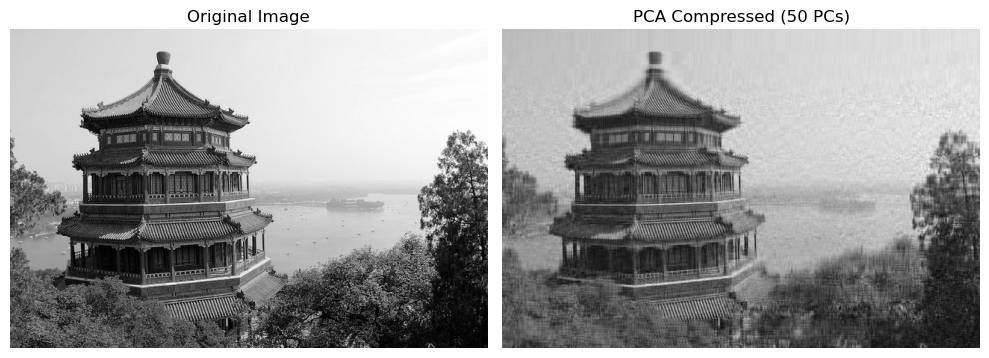

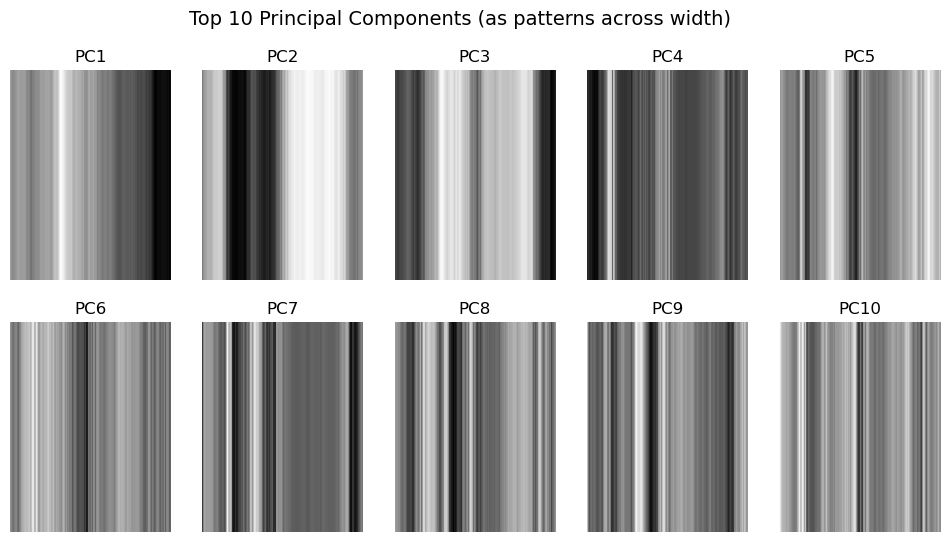

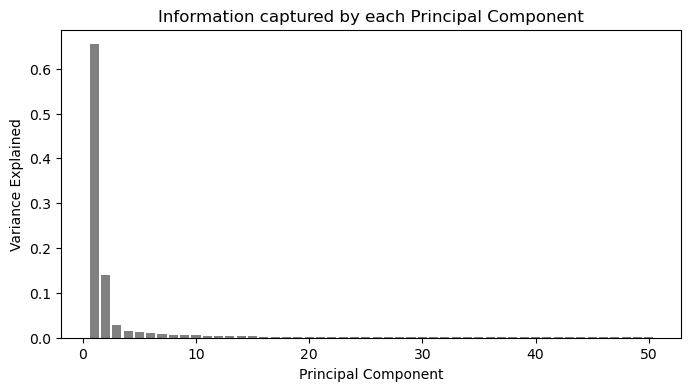

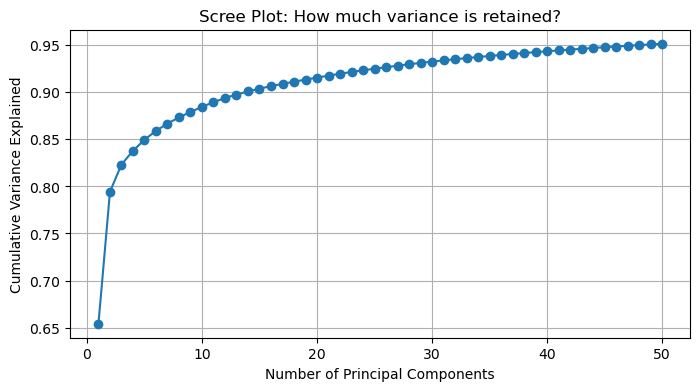

In [15]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_sample_image
import numpy as np

# ----------------------------------------------------------
# STEP 1: Load and preprocess the image
# ----------------------------------------------------------
china = load_sample_image("china.jpg")
gray = np.mean(china, axis=2) / 255.0  # convert RGB → grayscale (0-1 scale)
print("Original image shape:", gray.shape)

# ----------------------------------------------------------
# STEP 2: Apply PCA (retain 50 components)
# ----------------------------------------------------------
pca = PCA(n_components=50, random_state=42)
gray_pca = pca.fit_transform(gray)
gray_reconstructed = pca.inverse_transform(gray_pca)

print("PCA compressed shape:", gray_pca.shape)

# ----------------------------------------------------------
# STEP 3: Display Original vs PCA Reconstructed Image
# ----------------------------------------------------------
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(gray_reconstructed, cmap='gray')
plt.title("PCA Compressed (50 PCs)")
plt.axis('off')

plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# STEP 4: Visualize the top 10 principal components
# ----------------------------------------------------------
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(pca.components_[i].reshape(1, -1), cmap='gray', aspect='auto')
    plt.title(f"PC{i+1}")
    plt.axis('off')

plt.suptitle("Top 10 Principal Components (as patterns across width)", fontsize=14)
plt.show()

# ----------------------------------------------------------
# STEP 5: Variance explained by each component
# ----------------------------------------------------------
plt.figure(figsize=(8,4))
plt.bar(range(1, 51), pca.explained_variance_ratio_, color='gray')
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained")
plt.title("Information captured by each Principal Component")
plt.show()

# ----------------------------------------------------------
# STEP 6: Cumulative variance (Scree Plot)
# ----------------------------------------------------------
var_cumu = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8,4))
plt.plot(range(1,51), var_cumu, marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Variance Explained")
plt.title("Scree Plot: How much variance is retained?")
plt.grid(True)
plt.show()
